> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib seaborn numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Forward Selection — find the best feature subset
4. Data Preparation — selected features, train/test split **before** scaling, RobustScaler
5. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
6. Predict & Visualize
7. Evaluate — RMSE, MAE, MAPE

# 0. Setup and Dependencies

In [2]:
%pip install matplotlib seaborn numpy pandas scipy scikit-learn tensorflow yfinance fredapi vaderSentiment google-news-api dateparser --quiet
import yfinance as yf
from fredapi import Fred
import seaborn as sns
import numpy as np
import pandas as pd
import time, requests
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pointbiserialr

---
# 1. Fetching Stock Data

In [3]:
# ── Config ──────────────────────────────────────────────────────────────────
TICKER     = 'TSLA'          # Change to any yfinance-supported ticker
START_DATE = '2016-01-01'
END_DATE   = '2025-12-31'

stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE, multi_level_index=False)
print(f'Downloaded {len(stock_data)} rows for {TICKER}')
stock_data.tail()


/tmp/ipykernel_48185/187181836.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed

Downloaded 2513 rows for TSLA


,Close,High,Low,Open,Volume
Date,,,,,
2025-12-23,485.559998,491.970001,482.839996,489.399994,58223600
2025-12-24,485.399994,490.899994,476.799988,488.480011,41285400
2025-12-26,475.190002,489.089996,473.820007,485.230011,58780700
2025-12-29,459.640015,469.399994,459.000000,469.000000,66263000
2025-12-30,454.429993,463.119995,453.829987,461.089996,59238500


---
# 2. Generate All Candidate Features

### 2.0 Configuration

In [20]:
import os

# Set keys as environment variables (recommended) or paste them directly here.
# FRED key  : https://fred.stlouisfed.org/docs/api/api_key.html  (free)
# AV key    : https://www.alphavantage.co/support/#api-key        (free, 25 req/day)
FRED_API_KEY          = os.environ.get('FRED_API_KEY',   '5e48206e559ddc72e7679880d1a2534f')
ALPHA_VANTAGE_API_KEY = os.environ.get('ALPHA_VANTAGE_KEY', '29LQCTSDLAULW91P.')
# STOCK_DATA_API_KEY    = os.environ.get('STOCK_DATA_KEY', 'KeECt6siKwT3PBSwvwnjI8caKTpluzF51tE3YXh1')
# Pull macro data earlier so rolling windows are warm at TRAIN_START
MACRO_START = '2015-06-01'


### 2.1 Technical Features

In [5]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = stock_data.copy()

# --- Moving averages & volatility ---
for w in [5, 10, 20, 50]:
    df[f'SMA_{w}']        = df['Close'].rolling(w).mean()
    df[f'EMA_{w}']        = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

# RSI-14
df['RSI_14'] = 100 - 100 / (
    1 + df['Close'].diff().clip(lower=0).rolling(14).mean()
      / df['Close'].diff().clip(upper=0).abs().rolling(14).mean()
)

# MACD
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']        = ema12 - ema26
df['MACD_signal'] = df['MACD'].ewm(span=9).mean()
df['MACD_hist']   = df['MACD'] - df['MACD_signal']

# Bollinger Bands
sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

# ATR-14
high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

# OBV
df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']  = df['Close'].pct_change()
df['return_5d']  = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']   = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- Cyclical time features ---
# np.where avoids pandas ExtensionArray issues with is_leap_year
year_days = np.where(df.index.is_leap_year, 366, 365)
df['sin_year']    = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year']    = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

# isocalendar().week returns an ExtensionArray — cast to float before numpy ops
week_num = df.index.isocalendar().week.values.astype(float)
df['sin_week'] = np.sin(2 * np.pi * (week_num - 1) / 52)
df['cos_week'] = np.cos(2 * np.pi * (week_num - 1) / 52)

df['sin_month']   = np.sin(2 * np.pi * (df.index.month   - 1) / 12)
df['cos_month']   = np.cos(2 * np.pi * (df.index.month   - 1) / 12)
df['sin_quarter'] = np.sin(2 * np.pi * (df.index.quarter - 1) / 4)
df['cos_quarter'] = np.cos(2 * np.pi * (df.index.quarter - 1) / 4)

# Days since start - monotonic time feature (critical for trending stocks)
df['days_since_start'] = np.arange(len(df))

# Target: next-day close
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()

print(f'Technical features shape: {df.shape}')


Technical features shape: (2462, 42)


### 2.2 Macro Feature (Pulled from FRED)
| Series | FRED Code | Why It Helps |
|---|---|---|
| VIX | `VIXCLS` | Market fear gauge — spikes before and during crashes |
| Yield curve (10Y-2Y) | `T10Y2Y` | Inversion reliably precedes recessions |
| Fed Funds Rate | `FEDFUNDS` | Rate hike cycles crush tech/growth stocks |
| Credit spread (BAA-AAA) | computed | Widens before financial stress events |
| Unemployment | `UNRATE` | Lagging but useful for recession regime detection |

In [6]:
import pandas as pd
from fredapi import Fred


def fetch_macro_data(
    fred_api_key,
    start_date="2015-01-01",
    end_date="2025-12-31",
):
    """
    Fetch macroeconomic indicators from FRED and return a clean
    daily-frequency dataframe.

    Features:
    ---------
    - Pulls major macro indicators from FRED
    - Converts everything to daily frequency
    - Forward-fills monthly/weekly series
    - Adds derived recession/stress indicators
    - Handles missing series safely

    Parameters
    ----------
    fred_api_key : str
        FRED API key

    start_date : str
        Start date (YYYY-MM-DD)

    end_date : str
        End date (YYYY-MM-DD)

    Returns
    -------
    pd.DataFrame
        Daily macroeconomic feature dataframe
    """

    # ------------------------------------------------------------------
    # Validate API key
    # ------------------------------------------------------------------
    if not fred_api_key or fred_api_key == "YOUR_FRED_KEY_HERE":
        print("⚠️ No valid FRED API key provided.")
        print("Get a free key:")
        print("https://fred.stlouisfed.org/docs/api/api_key.html")
        return pd.DataFrame()

    fred = Fred(api_key=fred_api_key)

    # ------------------------------------------------------------------
    # FRED series mapping
    # ------------------------------------------------------------------
    SERIES = {
        "vix": "VIXCLS",
        "yield_curve": "T10Y2Y",
        "fed_funds": "FEDFUNDS",
        "baa_rate": "BAA",
        "aaa_rate": "AAA",
        "unemployment": "UNRATE",
    }

    # ------------------------------------------------------------------
    # Create master daily index
    # ------------------------------------------------------------------
    daily_index = pd.date_range(start=start_date, end=end_date, freq="D")

    frames = {}

    print("Fetching FRED macro data...\n")

    # ------------------------------------------------------------------
    # Download each series
    # ------------------------------------------------------------------
    for feature_name, fred_code in SERIES.items():

        try:
            series = fred.get_series(
                fred_code,
                observation_start=start_date,
                observation_end=end_date,
            )

            # Ensure datetime index
            series.index = pd.to_datetime(series.index)

            # Sort index
            series = series.sort_index()

            # Remove duplicates
            series = series[~series.index.duplicated(keep="first")]

            # Reindex to daily frequency
            series = series.reindex(daily_index)

            # Forward fill slower-moving data
            series = series.ffill()

            # Rename series
            series.name = feature_name

            frames[feature_name] = series

            print(
                f"✓ {feature_name:<15} "
                f"{fred_code:<10} "
                f"{series.notna().sum():>6} observations"
            )

        except Exception as e:
            print(f"✗ Failed: {feature_name} ({fred_code}) -> {e}")

    # ------------------------------------------------------------------
    # Combine all features
    # ------------------------------------------------------------------
    macro_df = pd.concat(frames.values(), axis=1)

    # ------------------------------------------------------------------
    # Derived Features
    # ------------------------------------------------------------------

    # Credit spread
    if {"baa_rate", "aaa_rate"}.issubset(macro_df.columns):
        macro_df["credit_spread"] = (
            macro_df["baa_rate"] - macro_df["aaa_rate"]
        )

    # Yield curve inversion
    if "yield_curve" in macro_df.columns:
        macro_df["yield_inverted"] = (
            macro_df["yield_curve"] < 0
        ).astype(int)

    # ------------------------------------------------------------------
    # VIX Features
    # ------------------------------------------------------------------
    if "vix" in macro_df.columns:

        # 252 trading days ≈ 1 year
        rolling_window = 252

        vix_roll_mean = macro_df["vix"].rolling(
            rolling_window,
            min_periods=30
        ).mean()

        # Spike indicator
        macro_df["vix_spike"] = (
            macro_df["vix"] > (vix_roll_mean * 1.5)
        ).astype(int)

        # Percentile rank
        macro_df["vix_percentile"] = (
            macro_df["vix"]
            .rolling(rolling_window, min_periods=30)
            .rank(pct=True)
        )

    # ------------------------------------------------------------------
    # Unemployment Trend
    # ------------------------------------------------------------------
    if "unemployment" in macro_df.columns:

        macro_df["unemployment_change_3m"] = (
            macro_df["unemployment"].diff(90)
        )

    # ------------------------------------------------------------------
    # Final Cleanup
    # ------------------------------------------------------------------

    # Remove leading NaNs from rolling features
    macro_df = macro_df.ffill()

    # Optional:
    # macro_df = macro_df.dropna()

    print("\nDone.")
    print(f"Macro DataFrame shape: {macro_df.shape}")

    return macro_df

macro_df = fetch_macro_data(FRED_API_KEY, MACRO_START, END_DATE)
if not macro_df.empty:
    macro_df.tail()

Fetching FRED macro data...



✓ vix             VIXCLS       3867 observations
✓ yield_curve     T10Y2Y       3867 observations
✓ fed_funds       FEDFUNDS     3867 observations
✓ baa_rate        BAA          3867 observations
✓ aaa_rate        AAA          3867 observations
✓ unemployment    UNRATE       3867 observations

Done.
Macro DataFrame shape: (3867, 11)


### 2.3 Sentiment Data (from Alpha Vantage News)

In [21]:
from datetime import datetime
from dateutil.relativedelta import relativedelta


def _normalize_sentiment_score(item):
    score = item.get('overall_sentiment_score')
    if score is not None:
        try:
            return float(score)
        except Exception:
            pass

    label = item.get('overall_sentiment_label') or item.get('overall_sentiment')
    if isinstance(label, str):
        label = label.strip().lower()
        if label == 'positive':
            return 1.0
        if label == 'negative':
            return -1.0
        if label == 'neutral':
            return 0.0

    return None


def fetch_alpha_vantage_news_sentiment(ticker, start_date=None, end_date=None):
    """
    Fetch Alpha Vantage News & Sentiment data for one ticker and aggregate daily scores.

    The free tier supports historical news sentiment, but it is rate-limited.
    We fetch year-sized chunks to collect a wide date range while staying within limits.
    """
    api_key = ALPHA_VANTAGE_API_KEY
    if not api_key or api_key == 'YOUR_KEY_HERE':
        print('⚠️  No Alpha Vantage API key set — returning empty sentiment frame.')
        print('   Get a free key at: https://www.alphavantage.co/support/#api-key')
        return pd.DataFrame()

    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    if start > end:
        return pd.DataFrame()

    records = []
    chunk_start = start

    while chunk_start <= end:
        chunk_end = min(chunk_start + relativedelta(years=1) - pd.Timedelta(seconds=1), end)
        time_from = chunk_start.strftime('%Y%m%dT%H%M')
        time_to = chunk_end.strftime('%Y%m%dT%H%M')

        params = {
            'function': 'NEWS_SENTIMENT',
            'tickers': ticker,
            'time_from': time_from,
            'time_to': time_to,
            'limit': 1000,
            'apikey': api_key,
        }

        print(f'\n\U0001f4f0 Fetching Alpha Vantage sentiment for {ticker}: {time_from} -> {time_to}')
        try:
            response = requests.get('https://www.alphavantage.co/query', params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
        except Exception as e:
            print(f'✗ Request failed for {time_from} -> {time_to}: {e}')
            break

        feed = data.get('feed') or data.get('items') or []
        if isinstance(feed, dict):
            feed = [feed]

        if not feed:
            print('  No feed items returned for this chunk.')
        else:
            for item in feed:
                published = item.get('time_published') or item.get('published_at') or item.get('published')
                if not published:
                    continue
                try:
                    pub_date = pd.to_datetime(published, utc=True).tz_convert(None).normalize()
                except Exception:
                    continue

                score = _normalize_sentiment_score(item)
                if score is None:
                    continue

                records.append({'Date': pub_date, 'sentiment_score': score})

        chunk_start = chunk_end + pd.Timedelta(seconds=1)
        time.sleep(1)

    if not records:
        print('⚠️  No sentiment records found for Alpha Vantage.')
        return pd.DataFrame()

    df_sent = pd.DataFrame(records)
    df_sent = df_sent.groupby('Date', sort=True)['sentiment_score'].mean().to_frame()
    df_sent.index.name = 'Date'

    print(f'✓ {len(df_sent)} daily sentiment rows  | avg score: {df_sent["sentiment_score"].mean():+.3f}')
    return df_sent


sentiment_df = fetch_alpha_vantage_news_sentiment(TICKER, START_DATE, END_DATE)

if sentiment_df.empty:
    print('No Alpha Vantage sentiment data fetched.')


📰 Fetching Alpha Vantage sentiment for TSLA: 20160101T0000 -> 20161231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20170101T0000 -> 20171231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20180101T0000 -> 20181231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20190101T0000 -> 20191231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20200101T0000 -> 20201231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20210101T0000 -> 20211231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20220101T0000 -> 20221231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20230101T0000 -> 20231231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20240101T0000 -> 20241231T2359

📰 Fetching Alpha Vantage sentiment for TSLA: 20250101T0000 -> 20251231T0000
✓ 1578 daily sentiment rows  | avg score: +0.115


In [22]:
sentiment_df.head()

,sentiment_score
Date,
2016-01-01,0.175989
2016-01-04,0.209455
2016-01-11,0.214880
2016-01-14,0.142677
2016-01-15,0.141410


In [23]:
os.makedirs('data', exist_ok=True)   # safe on Colab, Kaggle, VS Code, local

macro_df.to_csv('data/macro_data.csv')
sentiment_df.to_csv('data/sentiment.csv')
df.to_csv(f'data/stock_data_{TICKER}.csv')
print('\u2705 Raw data saved to data/')


✅ Raw data saved to data/


In [24]:
os.makedirs('data', exist_ok=True)   # safe on Colab, Kaggle, VS Code, local

stock_data.to_csv(f'data/stock_data_{TICKER}.csv')
macro_df.to_csv(f'data/macro_data_{TICKER}.csv')
sentiment_df.to_csv(f'data/sentiment_{TICKER}.csv')
df.to_csv(f'data/stock_data_{TICKER}.csv')
print('✔️ Raw data saved to data')

✔️ Raw data saved to data


## Data Pre-Processing

In [25]:
df = pd.read_csv(f'data/stock_data_{TICKER}.csv', index_col=0, parse_dates=True).copy()

### Merge and Clean Data

In [26]:
# Ensure all indices are timezone-naive datetime

def _to_utc_naive(idx):

    idx = pd.to_datetime(idx)

    return idx.tz_localize(None) if idx.tzinfo is not None else idx



df.index           = _to_utc_naive(df.index)

macro_df.index     = _to_utc_naive(macro_df.index)

sentiment_df.index = _to_utc_naive(sentiment_df.index)





def _resample_to_daily(src, target_index):

    """Forward-fill a lower-frequency frame to daily, keeping only numeric cols."""

    if src.empty:

        return pd.DataFrame(index=target_index)

    return (

        src.select_dtypes(include=[np.number])

           .reindex(target_index, method='ffill')

    )





macro_daily     = _resample_to_daily(macro_df,     df.index)

sentiment_daily = _resample_to_daily(sentiment_df, df.index)





# Safeguard: reload df from CSV if missing stock columns

if 'Close' not in df.columns or 'High' not in df.columns:

    print("WARNING: df missing stock columns, reloading from CSV...")

    df = pd.read_csv(f'data/stock_data_{TICKER}.csv', index_col=0, parse_dates=True)

    print(f'Reloaded df shape: {df.shape}')



# Debug: print original df before merge

print(f'Original df shape: {df.shape}')

print(f'Original df columns (first 10): {df.columns.tolist()[:10]}')



# Merge using pd.merge to handle column overlap properly

df_merged = df.copy()

print(f'df_merged copy shape: {df_merged.shape}')



# FIX BUG 1: Join macro/sentiment with LEFT join, ffill, only drop if target is missing

# Add macro data (forward-filled to daily)

df_merged = df_merged.join(macro_daily, how='left')

    macro_overlap = [c for c in macro_daily.columns if c in df_merged.columns]
    if macro_overlap:
        df_merged = df_merged.drop(columns=macro_overlap)

    macro_overlap = [c for c in macro_daily.columns if c in df_merged.columns]
    if macro_overlap:
        df_merged = df_merged.drop(columns=macro_overlap)
df_merged = df_merged.join(sentiment_daily, how='left')

    sentiment_overlap = [c for c in sentiment_daily.columns if c in df_merged.columns]
    if sentiment_overlap:
        df_merged = df_merged.drop(columns=sentiment_overlap)

    sentiment_overlap = [c for c in sentiment_daily.columns if c in df_merged.columns]
    if sentiment_overlap:
        df_merged = df_merged.drop(columns=sentiment_overlap)
print(f'df_merged shape after join: {df_merged.shape}')



# Forward fill macro columns only (they update at lower frequency)

macro_cols = [c for c in df_merged.columns if c in macro_df.columns]

for col in macro_cols:

    df_merged[col] = df_merged[col].ffill()

    # FIX BUG 5: Add availability flag for macro features (staleness indicator)

    df_merged[f'{col}_available'] = df_merged[col].notna().astype(float)



# Fill sentiment columns (sparse, mostly NaN)

sentiment_cols_new = ['sentiment_score', 'sentiment_weighted', 'article_count']

for col in sentiment_cols_new:

    if col in df_merged.columns:

        df_merged[col] = df_merged[col].fillna(0)

sentiment_cols_old = ['sentiment_mean', 'sentiment_pos', 'sentiment_neg']

for col in sentiment_cols_old:

    if col in df_merged.columns:

        df_merged[col] = df_merged[col].fillna(0)  # Fill missing sentiment with 0 (neutral)



# FIX BUG 1: Only drop rows where TARGET is missing (not entire row)

df = df_merged.dropna(subset=['Close'])

print(f'Merged shape after targeted dropna: {df.shape}')

print(f'Columns ({len(df.columns)}): {df.columns.tolist()[:10]}...')



# Recreate Close_nxt target column

df['Close_nxt'] = df['Close'].shift(-1)

df = df.dropna(subset=['Close_nxt'])  # Only drop last row where target is NaN

print(f'After adding Close_nxt: {df.shape}')


Original df shape: (2461, 64)
Original df columns (first 10): ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_5', 'EMA_5', 'Volatility_5', 'SMA_10', 'EMA_10']
df_merged copy shape: (2461, 64)


ValueError: columns overlap but no suffix specified: Index(['vix', 'yield_curve', 'fed_funds', 'baa_rate', 'aaa_rate',
       'unemployment', 'credit_spread', 'yield_inverted', 'vix_spike',
       'vix_percentile', 'unemployment_change_3m'],
      dtype='object')

In [ ]:
df.head()

In [ ]:
os.makedirs('data', exist_ok=True)
df.to_csv(f'data/stock_data_{TICKER}_final.csv')
print(f'\u2705 Merged dataset saved \u2192 data/stock_data_{TICKER}_final.csv')


✅ Merged dataset saved → data/stock_data_TSLA_final.csv


---
# 3. Feature Selection
**Computing MI Score**

Why not just use Pearson correlation instead?
- vix_spike is binary (0 or 1) — Pearson can't handle that properly
- sin_week / cos_week are cyclical — Pearson would underestimate their importance

In [27]:
df = pd.read_csv(f'data/stock_data_{TICKER}_final.csv', index_col=0, parse_dates=True)
print(f'Loaded {df.shape[0]} rows \u00d7 {df.shape[1]} columns')
df.head()


Loaded 2461 rows × 64 columns


,Close,High,Low,Open,Volume,SMA_5,EMA_5,Volatility_5,SMA_10,EMA_10,...,yield_curve_available,fed_funds_available,baa_rate_available,aaa_rate_available,unemployment_available,credit_spread_available,yield_inverted_available,vix_spike_available,vix_percentile_available,unemployment_change_3m_available
Date,,,,,,,,,,,,,,,,,,,,,
2016-03-16,14.795333,14.838667,14.468000,14.533333,52750500,14.241333,14.334582,0.019262,13.876600,13.877499,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2016-03-17,15.092000,15.233333,14.666667,14.764667,56743500,14.524000,14.587055,0.009993,14.080867,14.098324,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2016-03-18,15.516000,15.632000,15.204000,15.273333,70677000,14.860533,14.896703,0.009171,14.292200,14.356090,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2016-03-21,15.888000,15.992000,15.666667,15.689333,79617000,15.169466,15.227135,0.005442,14.512400,14.634624,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2016-03-22,15.616000,15.932667,15.504000,15.814000,64740000,15.381466,15.356757,0.018088,14.723333,14.813059,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [28]:
'''Target and Feature Creation'''
target_col = ['Close_nxt']

# Select only numeric columns (exclude Date, headline, and any other non-numeric)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in target_col]

After MI pre-filter (MI > 0.05 + protected pairs): 48 features


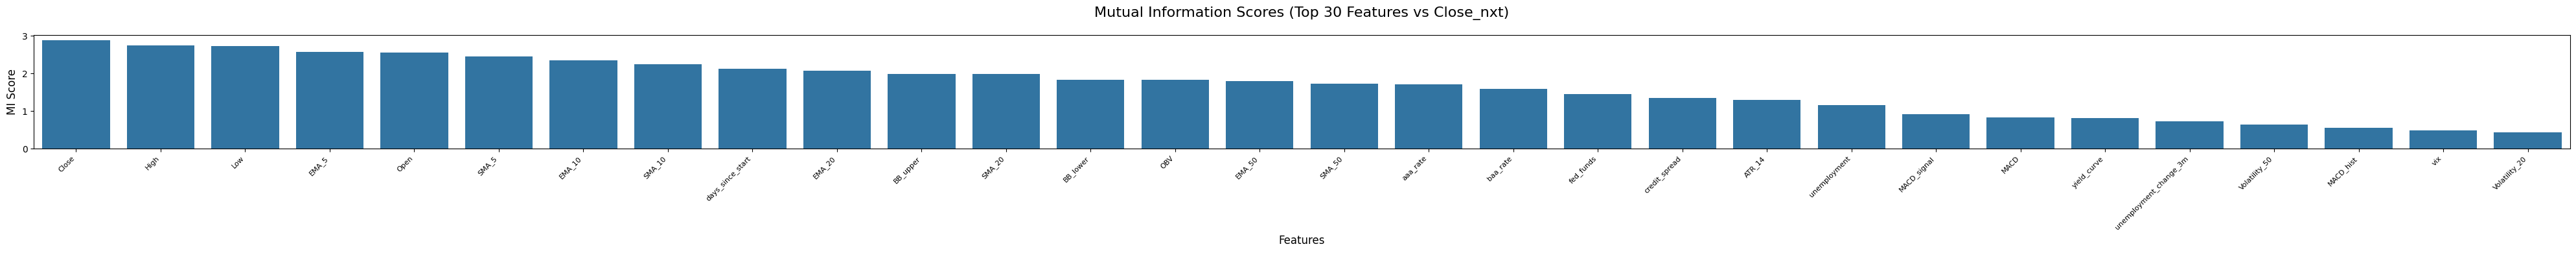


Top 15 Features by Mutual Information:
Close               2.877998
High                2.738436
Low                 2.728865
EMA_5               2.570620
Open                2.559086
SMA_5               2.456142
EMA_10              2.344459
SMA_10              2.238429
days_since_start    2.119081
EMA_20              2.064540
BB_upper            1.989900
SMA_20              1.983651
BB_lower            1.838575
OBV                 1.838347
EMA_50              1.791373
dtype: float64


In [29]:
# -------- MUTUAL INFORMATION PRE-FILTER  -------
# Pearson is inappropriate for binary features (vix_spike, yield_inverted) and loses cyclical info
from sklearn.feature_selection import mutual_info_regression

# Sample for faster computation
np.random.seed(42)
sample_size = min(1000, len(df))
sample_idx = np.random.choice(len(df), sample_size, replace=False)
X_sample = df[feature_cols].iloc[sample_idx].fillna(0).values  # Handle NaN
y_sample = df[target_col].iloc[sample_idx].values.ravel()

# Compute mutual information
mi = mutual_info_regression(X_sample, y_sample, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi, index=feature_cols)

# Keep features with MI > threshold
MI_THRESHOLD = 0.05
keep_mi = mi_series[mi_series > MI_THRESHOLD].index.tolist()

PROTECTED_PAIRS = [('sin_week','cos_week'), ('sin_month','cos_month'), 
                   ('sin_year','cos_year'), ('sin_quarter','cos_quarter')]
protected_cols = {c for pair in PROTECTED_PAIRS for c in pair}

feature_cols = [f for f in feature_cols if f in keep_mi or f in protected_cols]
print(f"After MI pre-filter (MI > {MI_THRESHOLD} + protected pairs): {len(feature_cols)} features")

# Visualize MI scores
plt.figure(figsize=(40, 4))
sns.barplot(x=mi_series.sort_values(ascending=False).index[:30], 
            y=mi_series.sort_values(ascending=False).values[:30])
plt.title("Mutual Information Scores (Top 30 Features vs Close_nxt)", fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("MI Score", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 15 Features by Mutual Information:")
print(mi_series.sort_values(ascending=False).head(15))

In [30]:
# ============ LASSO CV VOTING Feature Selection ======================
# Use TimeSeriesSplit to ensure no look-ahead bias in feature selection

# Prepare data (using only features, not target)
X = df[feature_cols].fillna(0).values
y = df[target_col].values.ravel()

# LASSO CV VOTING: Run LassoCV across 5 time-series folds, count how often each feature is selected
tscv = TimeSeriesSplit(n_splits=5)
selection_counts = np.zeros(len(feature_cols), dtype=int)

print("Running LASSO CV voting across 5 time-series folds (with per-fold scaling)...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, y_tr = X[train_idx], y[train_idx]
    
    # FIX BUG 4: Fit scaler ONLY on this fold's training data (no leakage!)
    scaler_fold = RobustScaler()
    X_tr_sc = scaler_fold.fit_transform(X_tr)
    
    # FIX BUG 3: Use LassoCV to auto-select best alpha via cross-validation
    lasso = LassoCV(cv=3, max_iter=10000, random_state=42, n_alphas=50)
    lasso.fit(X_tr_sc, y_tr.ravel())
    
    # Count which features were selected (non-zero coefficient)
    selected = (lasso.coef_ != 0).astype(int)
    selection_counts += selected
    
    selected_this_fold = np.sum(selected)
    print(f"  Fold {fold}: {selected_this_fold} features selected, best alpha={lasso.alpha_:.6f}")

# Keep features selected in at least 4/5 folds (like attempt3.5)
MIN_VOTES = 3
keep_mask = selection_counts >= MIN_VOTES
selected_features = [feature_cols[i] for i, keep in enumerate(keep_mask) if keep]

print(f"\nLASSO CV Voting Results (selected in >= {MIN_VOTES}/5 folds):")
print(f"Selected {len(selected_features)} features: {selected_features}")
print(f"\nFeature selection counts:")
for i, (feat, count) in enumerate(zip(feature_cols, selection_counts)):
    if count > 0:
        print(f"  {feat}: {count}/5")

Running LASSO CV voting across 5 time-series folds (with per-fold scaling)...
  Fold 1: 20 features selected, best alpha=0.003765


  Fold 2: 6 features selected, best alpha=0.021603
  Fold 3: 5 features selected, best alpha=0.353634
  Fold 4: 12 features selected, best alpha=0.139592
  Fold 5: 9 features selected, best alpha=0.370808

LASSO CV Voting Results (selected in >= 3/5 folds):
Selected 7 features: ['Close', 'High', 'Low', 'Volume', 'MACD_hist', 'days_since_start', 'unemployment_change_3m']

Feature selection counts:
  Close: 5/5
  High: 3/5
  Low: 3/5
  Open: 1/5
  Volume: 3/5
  Volatility_10: 1/5
  Volatility_20: 1/5
  SMA_50: 2/5
  EMA_50: 1/5
  Volatility_50: 1/5
  RSI_14: 1/5
  MACD_signal: 1/5
  MACD_hist: 3/5
  BB_upper: 1/5
  BB_lower: 1/5
  BB_width: 1/5
  ATR_14: 2/5
  OBV: 2/5
  high_low_ratio: 1/5
  cos_year: 1/5
  sin_quarter: 2/5
  cos_quarter: 1/5
  days_since_start: 3/5
  vix: 1/5
  yield_curve: 1/5
  aaa_rate: 2/5
  unemployment: 2/5
  credit_spread: 2/5
  unemployment_change_3m: 3/5


---
# 4. Data Preparation (using selected features)
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

In [31]:

LOOKBACK    = 60
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

TARGET_COL   = 'Close_nxt'
feature_cols = selected_features          # from lasso voting
if 'days_since_start' not in feature_cols:
    feature_cols.append('days_since_start')


n         = len(df)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

# Fit scalers on train only to prevent leakage
feat_scaler   = RobustScaler()
target_scaler = RobustScaler()

train_X = feat_scaler.fit_transform(df_train[feature_cols])
val_X   = feat_scaler.transform(df_val[feature_cols])
test_X  = feat_scaler.transform(df_test[feature_cols])

train_y = target_scaler.fit_transform(df_train[[TARGET_COL]])
val_y   = target_scaler.transform(df_val[[TARGET_COL]])
test_y  = target_scaler.transform(df_test[[TARGET_COL]])

# Alias kept for compatibility with downstream cells
scaler = feat_scaler

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)} rows')


Feature columns (7): ['Close', 'High', 'Low', 'Volume', 'MACD_hist', 'days_since_start', 'unemployment_change_3m']
Train: 1722  Val: 369  Test: 370 rows


In [32]:
def create_sequences(features, target, lookback):
    """Slide a lookback window over (features, target) to build (X, y) arrays."""
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)


# Train
X_train, y_train = create_sequences(train_X, train_y, LOOKBACK)

# Validation: prepend the last LOOKBACK rows of train so the first
# val sequence has full context (no look-ahead into val)
val_X_ctx = np.vstack([train_X[-LOOKBACK:], val_X])
val_y_ctx = np.vstack([train_y[-LOOKBACK:], val_y])
X_val, y_val = create_sequences(val_X_ctx, val_y_ctx, LOOKBACK)

# Test: same idea — prepend the last LOOKBACK rows of val
test_X_ctx = np.vstack([val_X[-LOOKBACK:], test_X])
test_y_ctx = np.vstack([val_y[-LOOKBACK:], test_y])
X_test, y_test = create_sequences(test_X_ctx, test_y_ctx, LOOKBACK)

# Index into original df for aligning predictions to dates
test_start_idx = val_end

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}    y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')


X_train: (1662, 60, 7)  y_train: (1662,)
X_val  : (369, 60, 7)    y_val  : (369,)
X_test : (370, 60, 7)   y_test : (370,)


---
# 5. Building and Training LSTM

In [33]:
# Force fresh hyperparameter tuning - delete cached tuner results
import shutil
import os
if os.path.exists('kt_results/lstm_tuning_v2'):
    shutil.rmtree('kt_results/lstm_tuning_v2')
    print("Deleted old kt_results - will run fresh hyperparameter tuning")
else:
    print("No existing kt_results found - starting fresh tuning")

# Hyperparameter tuning using KerasTuner (like attempt3.5)
%pip install keras-tuner tensorboard -q
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import keras

# Define model builder for KerasTuner
def build_model(hp):
    model = Sequential([
        Input(shape=(LOOKBACK, X_train.shape[2])),
        LSTM(
            hp.Int('units1', min_value=32, max_value=128, step=32),
            return_sequences=True
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        LSTM(
            hp.Int('units2', min_value=32, max_value=128, step=32),
            return_sequences=False
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[0.001, 0.0005])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Run Hyperband search
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory='kt_results',
    project_name='lstm_tuning_v2'
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best units1: {best_hp.get('units1')}")
print(f"Best units2: {best_hp.get('units2')}")
print(f"Best dropout: {best_hp.get('dropout')}")
print(f"Best learning_rate: {best_hp.get('learning_rate')}")

Trial 89 Complete [00h 00m 18s]
val_loss: 0.00814172625541687

Best val_loss So Far: 0.0057084341533482075
Total elapsed time: 00h 14m 26s
Best units1: 96
Best units2: 128
Best dropout: 0.2
Best learning_rate: 0.001


In [34]:
# Build final model with best hyperparameters
model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(best_hp.get('units1'), return_sequences=True),
    Dropout(best_hp.get('dropout')),
    LSTM(best_hp.get('units2'), return_sequences=False),
    Dropout(best_hp.get('dropout')),
    Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_hp.get('learning_rate')),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 96)         │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,265 (606.50 KB)

 Trainable params: 155,265 (606.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0564 - mae: 0.1372 - val_loss: 0.0329 - val_mae: 0.1390
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0130 - mae: 0.0732 - val_loss: 0.0145 - val_mae: 0.0939
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0111 - mae: 0.0666 - val_loss: 0.0237 - val_mae: 0.1207
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0090 - mae: 0.0589 - val_loss: 0.0204 - val_mae: 0.1162
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0107 - mae: 0.0642 - val_loss: 0.0101 - val_mae: 0.0785
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0076 - mae: 0.0547 - val_loss: 0.0095 - val_mae: 0.0675
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0065 - mae: 0.0506 - val_loss: 0.0147 - val_mae: 0.0979
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0068 - mae: 0.0501 - val_loss: 0.0112 - val_mae: 0.0850
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - lo

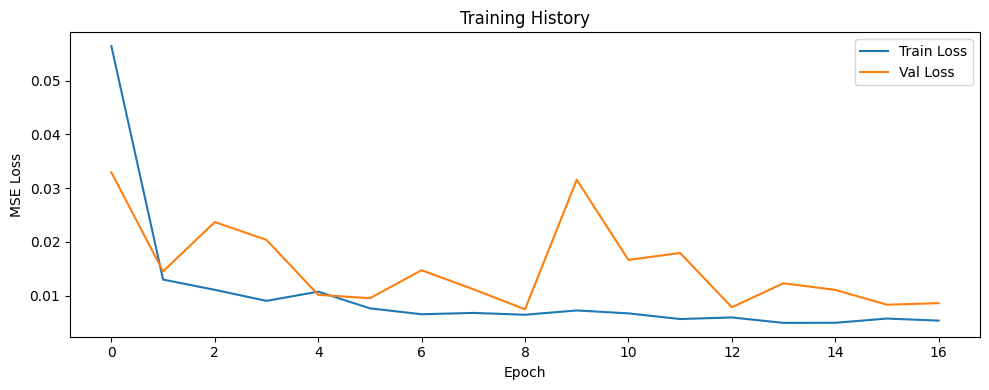

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [37]:
pred_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predictions shape: (370, 1)
Actuals shape     : (370, 1)


---
# 7. Visualisation

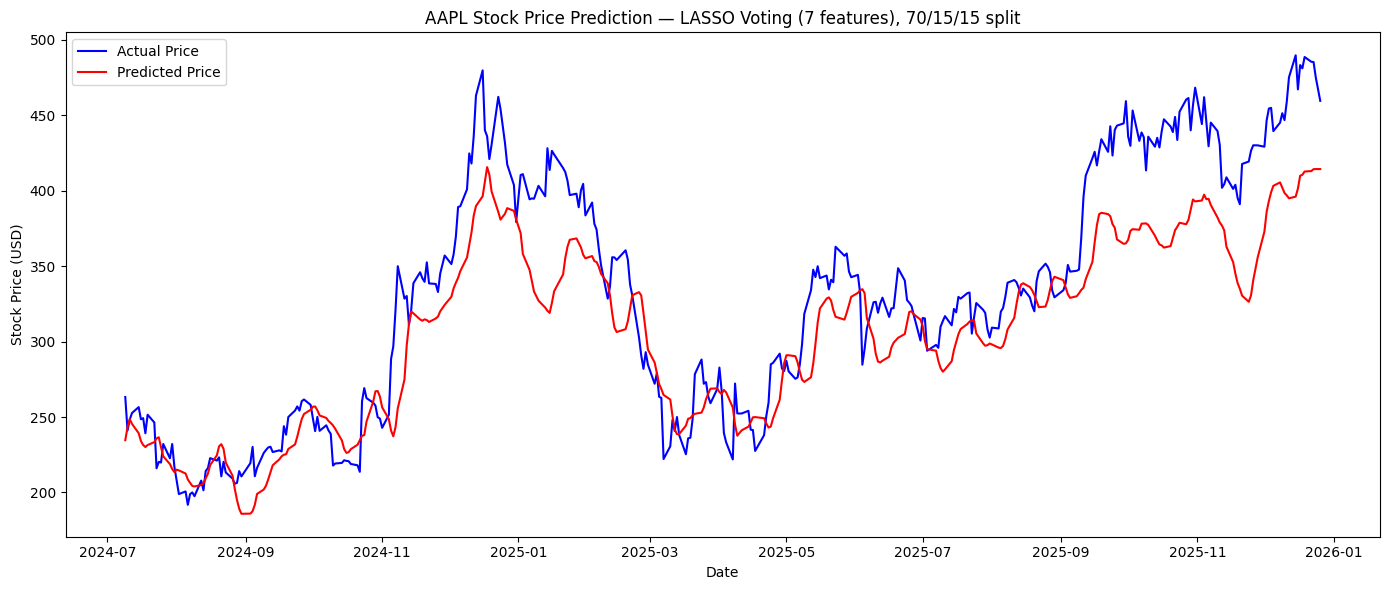

In [38]:
test_dates = df.index[test_start_idx:test_start_idx + len(X_test)]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price',    color='blue')
plt.plot(test_dates, prediction.flatten(),    label='Predicted Price', color='red')
plt.title(f'AAPL Stock Price Prediction \u2014 LASSO Voting '
          f'({len(feature_cols)} features), 70/15/15 split')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()


---
# 8. Model Evaluation

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 55)
print(f'LSTM with LASSO Voting Features ({len(feature_cols)}) - 70/15/15 split')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)

LSTM with LASSO Voting Features (7) - 70/15/15 split
Features: ['Close', 'High', 'Low', 'Volume', 'MACD_hist', 'days_since_start', 'unemployment_change_3m']
  MSE  : 1562.7625
  RMSE : 39.5318
  MAE  : 30.8305
  MAPE : 8.56%


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


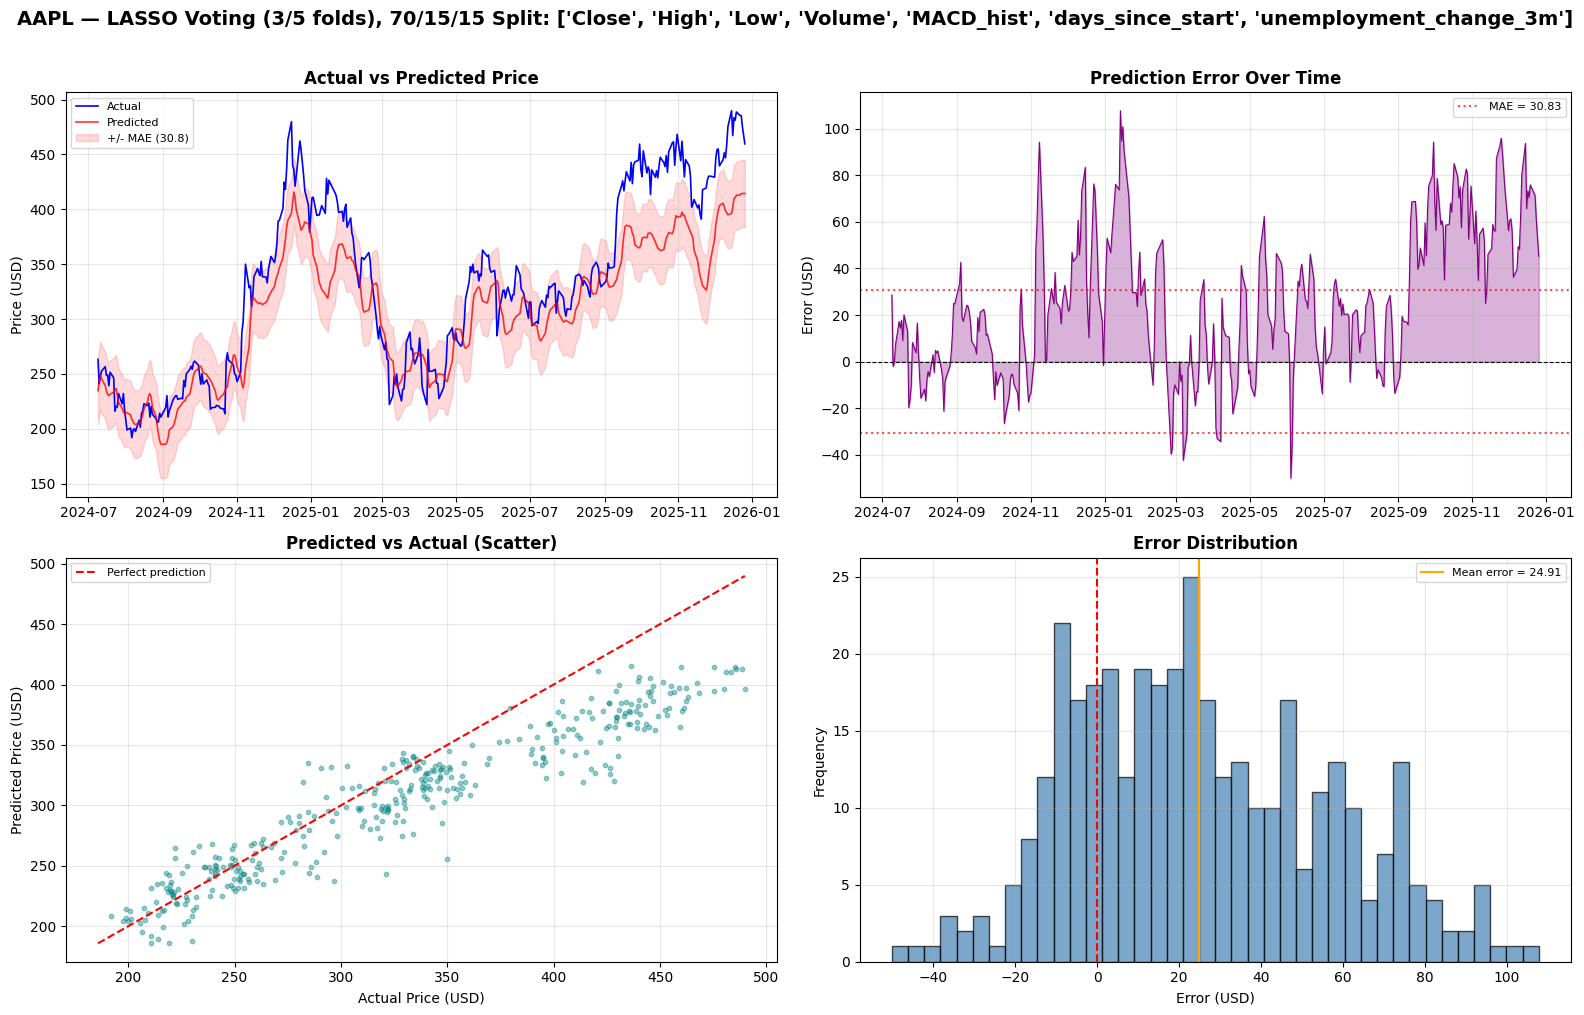

Mean Error: 24.9095  |  Std Error: 30.6966
Max Over-prediction: 107.7778  |  Max Under-prediction: -50.0700
Mean Abs % Error: 8.56%


In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_dates = df.index[test_start_idx:test_start_idx + len(X_test)]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'AAPL — LASSO Voting (3/5 folds), 70/15/15 Split: {feature_cols}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')